# Ablation Study — W1: Joint Hyperparameter Sweep (Wealth Objective)

**Objetivo:** encontrar a combinação de hiperparâmetros que maximiza o retorno financeiro, medido pela *wealth curve* final (`terminal_wealth = Π(1 + r_t)` iniciando em 1.0).

**Dimensões do sweep conjunto (5D):**
- `lambda_penalty` (Jump Penalty λ)
- `vol_estimator` (estimador de volatilidade)
- `n_regimes` (número de regimes)
- `recal_frequency` (frequência de recalibração)
- `forecaster_type` (modelo de previsão de regimes)

## Princípios metodológicos (research-grade)

1. **Ranking primário por `terminal_wealth_val` (janela de validação walk-forward)**, **não** no período de teste completo. Isto evita *hyperparameter leakage on backtest path*.
2. **Reporting honesto**: a config escolhida é reavaliada no **holdout** (`terminal_wealth_oos`) — nunca no mesmo intervalo usado para seleção.
3. **Diagnósticos obrigatórios** (robustez ao *path luck*): `max_drawdown`, `volatility`, `sharpe_ratio`, `turnover`, `n_position_switches`.
4. **Budget computacional explícito**: grid dimensionado para caber em `W1_BUDGET_MAX` combinações.
5. **Interpretabilidade**: decomposição de variância por fator (ANOVA-like) para atribuir quanto de `terminal_wealth` vem de cada dimensão (e não apenas de sorte na trajetória).

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.config.settings import (
    ASSETS, ASSET_TICKERS, FRED_SERIES, DATA_START, DATA_END,
    TEST_START, TEST_END,
)
from src.ablation import (
    ABLATION_W1_CONFIGS,
    W1_BUDGET_MAX,
    W1_VALIDATION_FRACTION,
    run_ablation_sweep,
    analyze_ablation,
    best_config_argmax,
)
from src.ablation.polars_utils import variance_decomposition_polars, float_nan_to_null

print(f'W1 grid size:        {len(ABLATION_W1_CONFIGS)} configs')
print(f'W1 budget:           {W1_BUDGET_MAX}')
print(f'Validation fraction: {W1_VALIDATION_FRACTION:.0%} (walk-forward)')
print(f'Test window:         {TEST_START} → {TEST_END}')

W1 grid size:        144 configs
W1 budget:           150
Validation fraction: 60% (walk-forward)
Test window:         2007-01-01 → 2023-12-31


## 1. Execução do Sweep (ou carga a partir do cache)

O sweep W1 é caro (product de 5 dimensões × ativos × seeds). Se já existe um `parquet` em `results/ablation/ablation_W1.parquet`, o notebook o carrega; caso contrário, executa. Para runs ad-hoc, use um subconjunto de ativos em `ASSETS_RUN`.

In [2]:
RESULTS_DIR = ROOT / 'results' / 'ablation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

W1_PATH = RESULTS_DIR / 'ablation_W1.parquet'
W1_ASSET_DIR = RESULTS_DIR / 'W1_asset_checkpoints'
W1_ASSET_DIR.mkdir(parents=True, exist_ok=True)
W1_LOG_PATH = W1_ASSET_DIR / 'run.log'

# Subset de ativos para demo. Em produção: ASSETS_RUN = list(ASSETS).
ASSETS_RUN = list(ASSETS)[:3]
N_BOOTSTRAP_W1 = 5
FORCE_W1_REBUILD = False

def log_w1(message: str) -> None:
    stamp = pd.Timestamp.now(tz='America/Fortaleza').strftime('%Y-%m-%d %H:%M:%S %Z')
    line = f'[{stamp}] {message}'
    print(line, flush=True)
    with open(W1_LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(line + '\n')

def w1_asset_path(asset: str) -> Path:
    safe_asset = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in asset)
    return W1_ASSET_DIR / f'ablation_W1_{safe_asset}.parquet'

W1_DF_CACHED = None
if W1_PATH.exists() and not FORCE_W1_REBUILD:
    W1_DF_CACHED = float_nan_to_null(pl.read_parquet(W1_PATH))
    cached_assets = set(W1_DF_CACHED.get_column('asset').unique().to_list())
    log_w1(f'Cache consolidado encontrado: {W1_PATH} ({W1_DF_CACHED.height} linhas; {len(cached_assets)} ativos).')
else:
    cached_assets = set()

if W1_DF_CACHED is not None:
    for asset in ASSETS_RUN:
        asset_path = w1_asset_path(asset)
        if asset in cached_assets and not asset_path.exists():
            asset_df = W1_DF_CACHED.filter(pl.col('asset') == asset)
            asset_df.write_parquet(asset_path)
            log_w1(f'Checkpoint criado a partir do cache consolidado: {asset} ({asset_df.height} linhas).')

completed_assets = [asset for asset in ASSETS_RUN if w1_asset_path(asset).exists() and not FORCE_W1_REBUILD]
pending_assets = [asset for asset in ASSETS_RUN if asset not in completed_assets]

log_w1(
    f'W1 sweep: {len(ASSETS_RUN)} ativos, {len(ABLATION_W1_CONFIGS)} configs, '
    f'{N_BOOTSTRAP_W1} seeds/config. Concluídos: {len(completed_assets)}; pendentes: {len(pending_assets)}.'
)

if pending_assets:
    log_w1('Carregando dados de mercado e fatores macro...')
    loader = DataLoader(cache_dir=str(ROOT / 'data' / 'raw'))
    prices   = loader.load_prices(ASSET_TICKERS, start=DATA_START, end=DATA_END)
    fred_raw = loader.load_fred(FRED_SERIES, start=DATA_START, end=DATA_END)
    preprocessor = DataPreprocessor()
    er, rf, fred = preprocessor.prepare(prices, fred_raw)
    log_w1('Dados preparados. Iniciando execução por ativo...')

    for asset_idx, asset in enumerate(pending_assets, start=1):
        asset_path = w1_asset_path(asset)
        t0 = pd.Timestamp.now()
        log_w1(f'[{asset_idx}/{len(pending_assets)}] Iniciando ativo {asset}: {len(ABLATION_W1_CONFIGS)} configs × {N_BOOTSTRAP_W1} seeds.')
        try:
            asset_df = run_ablation_sweep(
                ablation_id  = 'W1',
                assets       = [asset],
                er           = er,
                rf           = rf,
                fred         = fred,
                n_bootstrap  = N_BOOTSTRAP_W1,
                n_jobs       = 1,
            )
            asset_df = float_nan_to_null(asset_df)
            tmp_path = asset_path.with_suffix('.parquet.tmp')
            asset_df.write_parquet(tmp_path)
            tmp_path.replace(asset_path)
            elapsed_min = (pd.Timestamp.now() - t0).total_seconds() / 60
            log_w1(f'[{asset_idx}/{len(pending_assets)}] Finalizado {asset}: {asset_df.height} linhas salvas em {asset_path} ({elapsed_min:.1f} min).')
        except Exception as exc:
            elapsed_min = (pd.Timestamp.now() - t0).total_seconds() / 60
            log_w1(f'[{asset_idx}/{len(pending_assets)}] Falha em {asset} após {elapsed_min:.1f} min: {exc!r}')
            raise
else:
    log_w1('Todos os checkpoints por ativo já existem; pulando execução.')

asset_frames = [pl.read_parquet(w1_asset_path(asset)) for asset in ASSETS_RUN if w1_asset_path(asset).exists()]
if not asset_frames:
    raise RuntimeError('Nenhum checkpoint W1 disponível para consolidar.')

W1_DF = float_nan_to_null(pl.concat(asset_frames, how='vertical_relaxed'))
tmp_w1_path = W1_PATH.with_suffix('.parquet.tmp')
W1_DF.write_parquet(tmp_w1_path)
tmp_w1_path.replace(W1_PATH)
log_w1(f'Cache consolidado salvo em {W1_PATH} ({W1_DF.height} linhas; {W1_DF.get_column("asset").n_unique()} ativos).')

W1_DF.head(3)

[2026-04-28 20:10:46 -03] W1 sweep: 3 ativos, 144 configs, 5 seeds/config. Concluídos: 0; pendentes: 3.
[2026-04-28 20:10:46 -03] Carregando dados de mercado e fatores macro...
[2026-04-28 20:10:46 -03] Dados preparados. Iniciando execução por ativo...
[2026-04-28 20:10:46 -03] [1/3] Iniciando ativo LargeCap: 144 configs × 5 seeds.


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 288.2min finished


[2026-04-29 00:58:59 -03] [1/3] Finalizado LargeCap: 720 linhas salvas em /home/researcher/app/results/ablation/W1_asset_checkpoints/ablation_W1_LargeCap.parquet (288.2 min).
[2026-04-29 00:58:59 -03] [2/3] Iniciando ativo MidCap: 144 configs × 5 seeds.
[2026-04-29 04:33:23 -03] [2/3] Finalizado MidCap: 720 linhas salvas em /home/researcher/app/results/ablation/W1_asset_checkpoints/ablation_W1_MidCap.parquet (214.4 min).
[2026-04-29 04:33:23 -03] [3/3] Iniciando ativo SmallCap: 144 configs × 5 seeds.


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 214.4min finished


[2026-04-29 08:05:14 -03] [3/3] Finalizado SmallCap: 720 linhas salvas em /home/researcher/app/results/ablation/W1_asset_checkpoints/ablation_W1_SmallCap.parquet (211.8 min).
[2026-04-29 08:05:14 -03] Cache consolidado salvo em /home/researcher/app/results/ablation/ablation_W1.parquet (2160 linhas; 3 ativos).


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 211.8min finished


ablation_id,asset,config,seed,add,miss_rate,false_alarm_rate,cp_accuracy,cp_balanced_accuracy,accuracy,state_accuracy,state_balanced_accuracy,f1_score,total_return,volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,turnover,terminal_wealth,terminal_wealth_val,terminal_wealth_oos,n_position_switches,regime_ari,regime_agreement,mean_run_length,training_time_seconds,inference_time_ms
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""W1""","""LargeCap""","""w1_l25_cc_k2_mon_log""",0,3.566667,0.0,0.053214,0.941314,0.556726,0.856942,0.856942,0.883859,0.757335,0.208575,0.094214,2.043503,3.324325,-0.067172,2.866172,13.666199,31.951856,6.841948,4.669994,232.0,0.497337,0.856942,18.439655,46.911768,5.959667
"""W1""","""LargeCap""","""w1_l25_cc_k2_mon_log""",1,3.7,0.0,0.053449,0.941548,0.589942,0.8705,0.8705,0.895789,0.776793,0.222231,0.094311,2.186198,3.603003,-0.067172,3.069461,13.784011,40.274418,8.479688,4.749516,234.0,0.536283,0.8705,18.204255,51.653127,9.329167
"""W1""","""LargeCap""","""w1_l25_cc_k2_mon_log""",2,3.433333,0.0,0.051095,0.943418,0.557786,0.868396,0.868396,0.892054,0.772709,0.217447,0.094415,2.133121,3.480127,-0.067172,2.998253,13.077139,37.129002,7.379424,5.031423,222.0,0.529692,0.868396,19.183857,60.468198,26.552458


## 2. Seleção walk-forward (sem leakage)

A combinação *vencedora* é escolhida **exclusivamente** pela wealth terminal na janela de validação (`terminal_wealth_val`). O valor em `terminal_wealth` é reservado apenas para reporting final — **nunca** para seleção.

In [3]:
sel = best_config_argmax(
    W1_DF,
    metric='terminal_wealth_val',
    tiebreak_cols=[('max_drawdown', True), ('turnover', False)],
    higher_is_better=True,
)

print('--- Seleção (validação walk-forward) ---')
print(f"Config escolhida:       {sel['config']}")
print(f"terminal_wealth_val:    {sel['metric_value']:.4f}")
print(f"max_drawdown (mean):    {sel['details'].get('max_drawdown', float('nan')):.4f}")
print(f"turnover (mean):        {sel['details'].get('turnover', float('nan')):.4f}")

chosen = (
    W1_DF.filter(pl.col('config') == sel['config'])
         .select(['asset', 'seed', 'terminal_wealth',
                  'terminal_wealth_val', 'terminal_wealth_oos',
                  'max_drawdown', 'volatility', 'sharpe_ratio',
                  'turnover', 'n_position_switches'])
)
print('\n--- Diagnóstico agregado da config escolhida ---')
chosen.select(pl.all().exclude(['asset', 'seed']).mean()).to_pandas().T.round(4)

--- Seleção (validação walk-forward) ---
Config escolhida:       w1_l25_yz_k2_ann_log
terminal_wealth_val:    7.7293
max_drawdown (mean):    -0.1554
turnover (mean):        8.6474

--- Diagnóstico agregado da config escolhida ---


,0
terminal_wealth,26.4984
terminal_wealth_val,7.7293
terminal_wealth_oos,3.4901
max_drawdown,-0.1554
volatility,0.1435
sharpe_ratio,1.4021
turnover,8.6474
n_position_switches,146.8000


## 3. Ranking completo por `terminal_wealth_val` com diagnósticos

Mostrar as top-K configs **sempre** com risco/estabilidade ao lado da wealth. O ranking por wealth sem contexto de drawdown é um indicador perigoso (path dependence).

In [4]:
K = 10
ranking = (
    W1_DF.group_by('config')
         .agg([
             pl.col('terminal_wealth_val').mean().alias('wealth_val'),
             pl.col('terminal_wealth_oos').mean().alias('wealth_oos'),
             pl.col('terminal_wealth').mean().alias('wealth_full'),
             pl.col('max_drawdown').mean().alias('mdd'),
             pl.col('volatility').mean().alias('vol'),
             pl.col('sharpe_ratio').mean().alias('sharpe'),
             pl.col('turnover').mean().alias('turn'),
             pl.col('n_position_switches').mean().alias('n_switches'),
         ])
         .sort('wealth_val', descending=True)
         .head(K)
)
ranking

config,wealth_val,wealth_oos,wealth_full,mdd,vol,sharpe,turn,n_switches
str,f64,f64,f64,f64,f64,f64,f64,f64
"""w1_l25_cc_k2_ann_log""",7.729262,3.490116,26.498404,-0.155389,0.143543,1.402132,8.647405,146.8
"""w1_l25_yz_k2_ann_log""",7.729262,3.490116,26.498404,-0.155389,0.143543,1.402132,8.647405,146.8
"""w1_l25_yz_k2_sem_log""",6.575849,3.498766,23.760955,-0.195536,0.148939,1.331237,8.619916,146.333333
"""w1_l25_cc_k2_sem_log""",6.572127,3.498766,23.744436,-0.195536,0.148937,1.330923,8.619916,146.333333
"""w1_l25_cc_k2_qua_log""",6.530488,3.618708,24.513788,-0.190794,0.145874,1.367206,9.122581,154.866667
"""w1_l25_yz_k2_qua_log""",6.530488,3.618708,24.513788,-0.190794,0.145874,1.367206,9.122581,154.866667
"""w1_l25_yz_k3_ann_log""",6.207533,1.926879,11.187918,-0.179837,0.117045,1.226659,8.17223,138.733333
"""w1_l25_cc_k3_ann_log""",6.195716,1.926879,11.163647,-0.179837,0.117049,1.225765,8.17223,138.733333
"""w1_l25_cc_k2_mon_log""",6.076178,3.422911,21.628495,-0.164636,0.142798,1.323214,9.825526,166.8


## 4. Consistência validação ↔ holdout

Se o ranking por `terminal_wealth_val` discordar fortemente do ranking por `terminal_wealth_oos`, a seleção está capturando *path luck* e não estrutura — alerta para banca.

Pearson(val, oos):  0.611
Spearman rank corr: 0.609


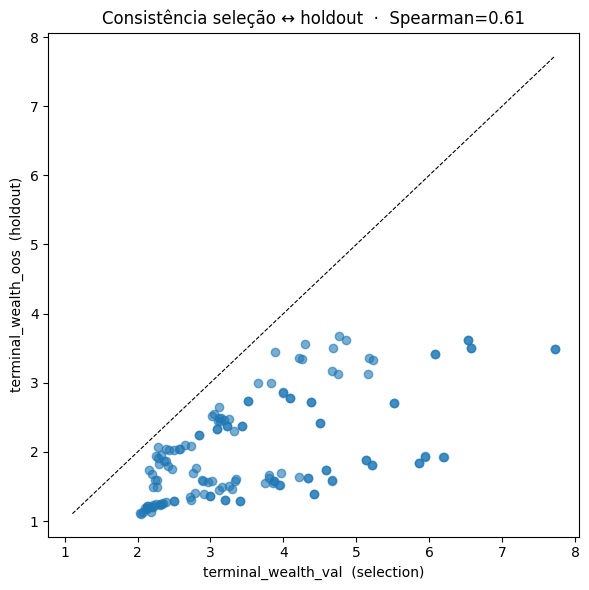

In [9]:
by_cfg = (
    W1_DF.group_by('config')
         .agg([
             pl.col('terminal_wealth_val').mean().alias('wealth_val'),
             pl.col('terminal_wealth_oos').mean().alias('wealth_oos'),
         ])
         .drop_nulls()
         .to_pandas()
)
rho = by_cfg[['wealth_val', 'wealth_oos']].corr().iloc[0, 1]
rank_rho = by_cfg[['wealth_val', 'wealth_oos']].rank().corr().iloc[0, 1]
print(f'Pearson(val, oos):  {rho:.3f}')
print(f'Spearman rank corr: {rank_rho:.3f}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(by_cfg['wealth_val'], by_cfg['wealth_oos'], alpha=0.6)
numeric = by_cfg[['wealth_val', 'wealth_oos']]
lim = [numeric.min().min(), numeric.max().max()]
ax.plot(lim, lim, 'k--', lw=0.8)
ax.set_xlabel('terminal_wealth_val  (selection)')
ax.set_ylabel('terminal_wealth_oos  (holdout)')
ax.set_title(f'Consistência seleção ↔ holdout  ·  Spearman={rank_rho:.2f}')
plt.tight_layout(); plt.show()

## 5. Atribuição de variância (interpretabilidade)

Decomposição ANOVA-like: quanto da variância de `terminal_wealth_val` cada fator isolado explica? Em um sweep conjunto sem decomposição, ganhos podem vir de interações puras — a banca vai perguntar *qual mecanismo moveu a wealth*.

In [10]:
def _parse_w1_name(name: str):
    parts = name.split('_')
    return {
        'lambda_penalty':  int(parts[1].lstrip('l')),
        'vol_estimator':   parts[2],
        'n_regimes':       int(parts[3].lstrip('k')),
        'recal_frequency': parts[4],
        'forecaster_type': parts[5],
    }

_factors_pd = pd.DataFrame([
    _parse_w1_name(n) for n in W1_DF['config'].to_list()
])
W1_FACTORS = W1_DF.hstack(pl.from_pandas(_factors_pd))

vd = variance_decomposition_polars(
    W1_FACTORS.drop_nulls(subset=['terminal_wealth_val']),
    factor_cols=['lambda_penalty', 'vol_estimator', 'n_regimes',
                 'recal_frequency', 'forecaster_type'],
    metric_col='terminal_wealth_val',
)
vd

factor,ss_between,pct_variance,rank
str,f64,f64,i64
"""lambda_penalty""",1736.901621,51.812834,1
"""forecaster_type""",1335.892208,39.850478,2
"""recal_frequency""",211.000044,6.29426,3
"""n_regimes""",68.147859,2.032892,4
"""vol_estimator""",0.319669,0.009536,5


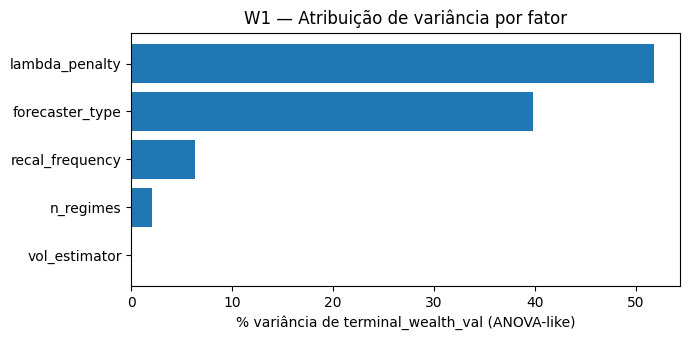

In [12]:
vd_pd = vd.to_pandas().sort_values('pct_variance')
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(vd_pd['factor'], vd_pd['pct_variance'])
ax.set_xlabel('% variância de terminal_wealth_val (ANOVA-like)')
ax.set_title('W1 — Atribuição de variância por fator')
plt.tight_layout(); plt.show()

## 6. Perfil de risco da config vencedora

Relatório final que a banca espera ver em conjunto: wealth + risco + estabilidade.

In [11]:
def fmt(v, d=4):
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return 'NaN'
    return f'{v:.{d}f}'

chosen_pd = chosen.to_pandas()
summary = {
    'config (argmax val)':    sel['config'],
    'wealth_val (selection)': fmt(chosen_pd['terminal_wealth_val'].mean()),
    'wealth_oos (holdout)':   fmt(chosen_pd['terminal_wealth_oos'].mean()),
    'wealth_full (report)':   fmt(chosen_pd['terminal_wealth'].mean()),
    'sharpe_ratio':           fmt(chosen_pd['sharpe_ratio'].mean()),
    'max_drawdown':           fmt(chosen_pd['max_drawdown'].mean()),
    'volatility':             fmt(chosen_pd['volatility'].mean()),
    'turnover':               fmt(chosen_pd['turnover'].mean()),
    'n_position_switches':    fmt(chosen_pd['n_position_switches'].mean(), 1),
}
pd.DataFrame(summary, index=['mean']).T

,mean
config (argmax val),w1_l25_yz_k2_ann_log
wealth_val (selection),7.7293
wealth_oos (holdout),3.4901
wealth_full (report),26.4984
sharpe_ratio,1.4021
max_drawdown,-0.1554
volatility,0.1435
turnover,8.6474
n_position_switches,146.8
